# **<center>12_eval_exp05_projection_shift_ap_abd</center>**

### Table of Contents

1. **Experiment Overview**
   - Objective of Experiment 5  
   - Internal test set description (Institution 1, AP and AB projections)  
   - Rationale: projection shift vs. training views (internal / external rotation)  

2. **Environment Setup**
   - Import of required libraries  

3. **Load Internal AP/AB Test Data**
   - Load image paths for AP/AB subsets  
   - Load metadata (CSV)  
   - Build dictionaries for internal subsets  

4. **Load Best CNN Model**
   - Model loading  
   - Summary of model architecture  

5. **Model Evaluation on AP / AB Projections**

   - Predict probabilities for all AP / AB images
   - Evaluation on AP projection  
   - Evaluation on abduction projection  
   - Global performance on combined AP + AB set  
   - Thresholds per projection (Youden index from validation)  
   - Full metrics: Sensitivity, Specificity, PPV, NPV, F1, Accuracy  
   - AUC confidence intervals (90–95–99%)

7. **Model Explainability**
   - Heatmap generation on AP/AB radiographs  
   - Representative examples (TP, TN, FP, FN) per subset  
   - Qualitative assessment of model focus on tendon calcifications  

8. **Summary and Conclusions**



### **1. Experiment Overview**

In Experiment 5 we evaluate the ability of the best convolutional neural network (CNN) obtained in Experiment 1 to generalize to radiographic projections that were not used during training. The model was trained exclusively on shoulder radiographs acquired in internal and external rotation at Institution 1 and is tested here on an internal dataset from the same institution composed of anterior–posterior (AP) and abduction (AB) projections. The goal is to assess whether a model developed on a specific acquisition protocol can maintain clinically useful performance when exposed to different geometric configurations of the same anatomical region.


The internal AP/AB test set consists of 152 anonymized shoulder radiographs (151 remaining after secondary cleaning and projection filtering) acquired at Institution 1 and grouped into four subsets according to the acquisition system:

- **TC_AP_ABD_CZC_HURJC_test**: 20 images  
- **TC_AP_ABD_HRJ_HURJC_test**: 40 images  
- **TC_AP_ABD_RAD_HURJC_test**: 64 images 
- **TC_AP_ABD_MIN_HURJC_test**: 28 images

Each image is labeled for the presence or absence of rotator cuff tendon calcifications, following the same binary definition used in the internal experiments. No patient-identifying information is stored or used in this notebook.


This experiment is designed to characterize the effect of projection shift within a single institution, isolating geometric changes while keeping scanner, population and clinical workflow constant. By evaluating the model separately on AP and AB projections, and on the combined AP+AB test set, we investigate how robust the learned representations are to changes in shoulder orientation and radiographic geometry. This internal validation setting provides insight into whether training on a limited set of projections is sufficient for reliable use in routine practice, or whether explicit inclusion of diverse projections and/or geometric normalization strategies is required to achieve stable performance across acquisition protocols.


### **2. Environment Setup: Import required libraries**

In [21]:
# Standard libraries
import os
from pathlib import Path
from datetime import datetime

# Scientific computing and data handling
import numpy as np
import pandas as pd
import math

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2

# Jupyter display utilities
from IPython.display import display

# Progress bar
from tqdm import tqdm

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Conv2D, SeparableConv2D, DepthwiseConv2D

# Scikit-learn metrics 
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Statistics
from scipy import stats


### **3. Load External Test Data**


#### **3.1. Load images**

In [22]:
# Base path where the internal AP/abduction test subsets are stored
subsets_path = 'Database/Second_database/Subsets'

# Dictionary to store the image paths for each internal test subset
internal_subsets = {
    'TC_AP_ABD_CZC_HURJC_test': [],
    'TC_AP_ABD_HRJ_HURJC_test': [],
    'TC_AP_ABD_RAD_HURJC_test': [],
    'TC_AP_ABD_MIN_HURJC_test': []
}

# Populate each subset list with the full paths to all .npy images
for subset_name in internal_subsets.keys():
    subset_dir = os.path.join(subsets_path, subset_name)
    
    image_paths = [
        os.path.join(subset_dir, img_name)
        for img_name in os.listdir(subset_dir)
        if img_name.endswith('.npy')
    ]
    
    internal_subsets[subset_name] = image_paths
    
    # Print how many images were found in each internal test subset
    print(f'Images in {subset_name}: {len(image_paths)}')


Images in TC_AP_ABD_CZC_HURJC_test: 20
Images in TC_AP_ABD_HRJ_HURJC_test: 40
Images in TC_AP_ABD_RAD_HURJC_test: 64
Images in TC_AP_ABD_MIN_HURJC_test: 28


In [23]:
# Load images
def load_images(images_path):
    X_list = []
    for image_path in images_path:
        X_ = np.load(image_path)
        X_list.append(X_)
    return np.array(X_list)
    

In [4]:
# Dictionary to store the loaded arrays
X_internal_dict = {}

for subset_name, image_paths in internal_subsets.items():
    print(f'\n🔍 Loading images from subset: {subset_name}')
    X_internal_dict[subset_name] = load_images(image_paths)
    print(f' Loaded {X_internal_dict[subset_name].shape[0]} images from {subset_name}')



🔍 Loading images from subset: TC_AP_ABD_CZC_HURJC_test
✅ Loaded 20 images from TC_AP_ABD_CZC_HURJC_test

🔍 Loading images from subset: TC_AP_ABD_HRJ_HURJC_test
✅ Loaded 40 images from TC_AP_ABD_HRJ_HURJC_test

🔍 Loading images from subset: TC_AP_ABD_RAD_HURJC_test
✅ Loaded 64 images from TC_AP_ABD_RAD_HURJC_test

🔍 Loading images from subset: TC_AP_ABD_MIN_HURJC_test
✅ Loaded 28 images from TC_AP_ABD_MIN_HURJC_test


#### **3.2. Load metadata**

In [5]:
# Dictionary to store the DataFrames containing metadata for each internal subset
df_internal_dict = {}

# Load CSV files associated with each internal AP/abduction test subset
for subset_name in internal_subsets.keys():
    csv_path = os.path.join(subsets_path, subset_name + '.csv')
    df = pd.read_csv(csv_path)
    df_internal_dict[subset_name] = df

    # Print only the number of rows for safety (no sensitive metadata displayed)
    print(f'📄 Rows in {subset_name}: {df.shape[0]}')
    
# Merge all arrays from the external subsets into a single array
X_all = np.concatenate(list(df_internal_dict.values()), axis=0)
print(f'✅ All images concatenated: {X_all.shape}')


📄 Rows in TC_AP_ABD_CZC_HURJC_test: 20
📄 Rows in TC_AP_ABD_HRJ_HURJC_test: 40
📄 Rows in TC_AP_ABD_RAD_HURJC_test: 64
📄 Rows in TC_AP_ABD_MIN_HURJC_test: 28
✅ All images concatenated: (152, 20)


In [6]:
#Extract labels for a list of image paths based on metadata stored in a DataFrame

def extract_labels(df, image_paths):
    # Create a dictionary mapping image code → label
    label_dict = dict(zip(df['rx_cod'], df['label_CalTend']))

    # Retrieve labels based on the filename (without extension)
    y = np.array([
        label_dict[os.path.splitext(os.path.basename(path))[0]]
        for path in image_paths
    ])

    return y
    

#### **3.3. Build dictionaries for subsets** 

In [7]:
# Dictionary to store the labels for each internal subset
y_internal_dict = {}

# Extract labels for each subset
for subset_name in internal_subsets.keys():
    print(f'Extracting labels for {subset_name}')

    image_paths = internal_subsets[subset_name]
    df = df_internal_dict[subset_name]

    # Get the labels using the metadata DataFrame and image paths
    y = extract_labels(df, image_paths)
    y_internal_dict[subset_name] = y

    print(f'Labels extracted: {len(y)}')
    

🏷️ Extracting labels for TC_AP_ABD_CZC_HURJC_test
✅ Labels extracted: 20
🏷️ Extracting labels for TC_AP_ABD_HRJ_HURJC_test
✅ Labels extracted: 40
🏷️ Extracting labels for TC_AP_ABD_RAD_HURJC_test
✅ Labels extracted: 64
🏷️ Extracting labels for TC_AP_ABD_MIN_HURJC_test
✅ Labels extracted: 28


In [8]:
# Merge all image arrays into a single NumPy array
X_all = np.concatenate(
    [X_internal_dict[name] for name in internal_subsets.keys()],
    axis=0
)
print(f'✅ Total images: {X_all.shape}')

# Merge all label arrays into a single NumPy array
y_all = np.concatenate(
    [y_internal_dict[name] for name in internal_subsets.keys()],
    axis=0
)
print(f'✅ Total labels: {y_all.shape}')

# Merge all metadata DataFrames into a single DataFrame
df_all = pd.concat(
    [df_internal_dict[name] for name in internal_subsets.keys()],
    axis=0
).reset_index(drop=True)
print(f'📄 Total rows in df_all: {df_all.shape}')

# Final consistency check
assert X_all.shape[0] == y_all.shape[0] == df_all.shape[0], \
    "Mismatch between images, labels, or metadata"


✅ Total images: (152, 512, 512, 3)
✅ Total labels: (152,)
📄 Total rows in df_all: (152, 20)


In [10]:
# Build combined metadata and image set for AP / AB projections

subset_names = list(df_internal_dict.keys())

# Concatenate all metadata and keep track of the subset origin
df_list = []
for subset_name in subset_names:
    df_tmp = df_internal_dict[subset_name].copy()
    df_tmp['subset'] = subset_name   # store the full subset name
    df_list.append(df_tmp)

df_conjunto = pd.concat(df_list, ignore_index=True)
print(f"Total rows before projection filtering: {df_conjunto.shape[0]}")

# Keep only AP and AB projections
df_conjunto = df_conjunto[df_conjunto['proje'].isin(['AP', 'AB'])].copy()
print(f"Rows after filtering to AP / AB: {df_conjunto.shape[0]}")

# Sort by rx_cod for reproducibility
df_conjunto = df_conjunto.sort_values('rx_cod').reset_index(drop=True)

# Load images in the same order as df_conjunto
X_test_total = np.array([
    np.load(os.path.join(subsets_path, row['subset'], row['rx_cod'] + '.npy'))
    for _, row in df_conjunto.iterrows()
])

print("X_test_total shape:", X_test_total.shape)
assert X_test_total.shape[0] == df_conjunto.shape[0], "Mismatch between images and metadata rows!"


Total rows before projection filtering: 152
Rows after filtering to AP / AB: 151
X_test_total shape: (151, 512, 512, 3)


### **4. Load Best CNN Model**

In [9]:
# Path to the best CNN model
model_path = (
    'Models/best_cnn_model'
)

# Load the trained model
model = load_model(model_path)

# Display model summary
print('EXPERIMENT 1 — Best CNN model:')
model.summary()


2025-12-05 08:21:02.037125: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-05 08:21:02.083292: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-05 08:21:02.088181: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

EXPERIMENT 1 — Best CNN model:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 16, 16, 512)       20024384  
                                                                 
 global_max_pooling2d (Glob  (None, 512)               0         
 alMaxPooling2D)                                                 
                                                                 
 dense (Dense)               (None, 1)                 513       
                                                                 
Total params: 20024897 (76.39 MB)
Trainable params: 20024897 (76.39 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### **5. Model Evaluation on Internal Subsets AP/AB projection**

In [12]:
# Predict probabilities for all AP / AB images and attach to df_conjunto

y_probs_total = model.predict(X_test_total).flatten()
assert len(y_probs_total) == len(df_conjunto), "Mismatch between predictions and df_conjunto!"

# Store continuous prediction scores
df_conjunto['y_pred_prob'] = y_probs_total

# Optional: projection-specific binary prediction (AP / AB thresholds from Youden index)
thresholds_dict = {"AP": 0.05, "AB": 0.26}

df_conjunto['predicted_label'] = df_conjunto.apply(
    lambda row: int(row['y_pred_prob'] >= thresholds_dict.get(row['proje'], 0.5)),
    axis=1
)

print("✅ Updated DataFrame columns:")
print(df_conjunto.columns.tolist())


2025-12-05 08:26:43.375826: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600


5/5 [==============================] - 33s 4s/step
✅ Updated DataFrame columns:
['Unnamed: 0', 'index', 'NHC', 'epi_cod', 'rx_cod', 'proje', 'manufacturer', 'manufacturer_model', 'station_name', 'voilutfunction', 'birthdate', 'sex', 'ei', 'date_rx', 'label_CalTend', 'complentary_expl', 'label_CalTend_sub', 'label_CalTend_supr', 'label_CalTend_infr', 'lat_rx', 'subset', 'y_pred_prob', 'predicted_label']



=== Evaluation: AP projection ===
Confusion matrix:
[[32 7]
 [7 30]]

Fixed threshold (Youden-based for AP/AB): 0.05
Sensitivity: 0.8108
Specificity: 0.8205
PPV: 0.8108
NPV: 0.8205
F1 score: 0.8108
Accuracy: 0.8158
ROC AUC: 0.8829
CI 90%: [0.8167 – 0.9491]
CI 95%: [0.804 – 0.9617]
CI 99%: [0.7792 – 0.9865]

=== Evaluation: AB projection ===
Confusion matrix:
[[24 13]
 [22 16]]

Fixed threshold (Youden-based for AP/AB): 0.26
Sensitivity: 0.4211
Specificity: 0.6486
PPV: 0.5517
NPV: 0.5217
F1 score: 0.4776
Accuracy: 0.5333
ROC AUC: 0.4936
CI 90%: [0.3832 – 0.604]
CI 95%: [0.3621 – 0.6251]
CI 99%: [0.3207 – 0.6665]

=== Evaluation: AP + AB (combined) ===
Confusion matrix:
[[61 15]
 [37 38]]

Fixed threshold (Youden-based for AP/AB): 0.5
Sensitivity: 0.5067
Specificity: 0.8026
PPV: 0.717
NPV: 0.6224
F1 score: 0.5938
Accuracy: 0.6556
ROC AUC: 0.7302
CI 90%: [0.6629 – 0.7974]
CI 95%: [0.65 – 0.8103]
CI 99%: [0.6248 – 0.8355]


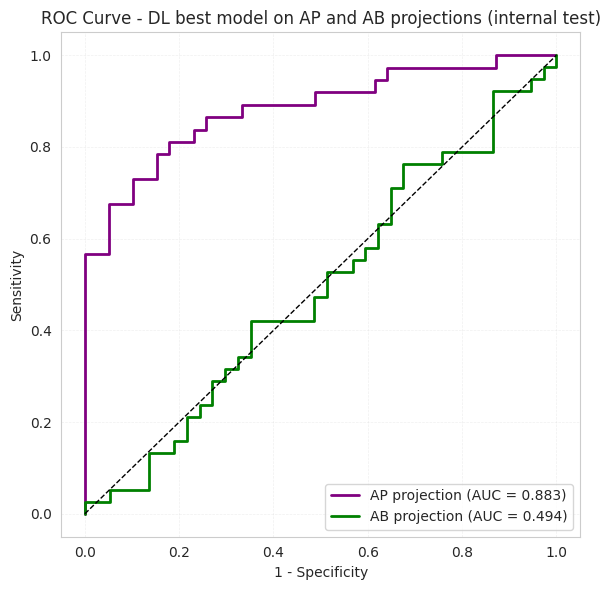

,Evaluation_name,cut_off_threshold_point,tn,fp,fn,tp,sensitivity,specificity,PPV,NPV,F1_score,accuracy,ROC_AUC,CI_90_lower,CI_90_upper,CI_95_lower,CI_95_upper,CI_99_lower,CI_99_upper
0,AP projection,0.05,32,7,7,30,0.8108,0.8205,0.8108,0.8205,0.8108,0.8158,0.8829,0.8167,0.9491,0.8040,0.9617,0.7792,0.9865
1,AB projection,0.26,24,13,22,16,0.4211,0.6486,0.5517,0.5217,0.4776,0.5333,0.4936,0.3832,0.6040,0.3621,0.6251,0.3207,0.6665
2,AP + AB (combined),0.50,61,15,37,38,0.5067,0.8026,0.7170,0.6224,0.5938,0.6556,0.7302,0.6629,0.7974,0.6500,0.8103,0.6248,0.8355


In [13]:
# Evaluation — Experiment 5: Internal test on AP / AB projections

# Base path to save evaluation outputs for Experiment 5
base_save_path = 'Evaluation/EXP5'
os.makedirs(base_save_path, exist_ok=True)


def auc_confidence_interval(y_true, y_score):
    """
    Compute the AUC and its confidence intervals using the method of
    Hanley & McNeil for binormal ROC curves.

    Parameters
    ----------
    y_true : array-like
        Binary ground-truth labels (0/1).
    y_score : array-like
        Predicted probabilities or continuous scores.

    Returns
    -------
    auc : float
        Area under the ROC curve.
    ci : dict
        Dictionary with lower and upper bounds for 90%, 95% and 99% CIs.
    """
    auc = roc_auc_score(y_true, y_score)
    n1 = sum(y_true)
    n2 = len(y_true) - n1
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    se_auc = np.sqrt(
        (auc * (1 - auc) +
         (n1 - 1) * (q1 - auc**2) +
         (n2 - 1) * (q2 - auc**2)) / (n1 * n2)
    )

    z = {0.90: 1.6449, 0.95: 1.96, 0.99: 2.5758}
    ci = {}
    for level in z:
        delta = z[level] * se_auc
        ci[f'CI {int(level * 100)}% lower'] = max(0, auc - delta)
        ci[f'CI {int(level * 100)}% upper'] = min(1, auc + delta)
    return auc, ci


# Thresholds per projection (chosen using Youden index on a separate validation set)
projection_thresholds = {
    'AP': 0.05,
    'AB': 0.26,
}

# Build evaluation dictionary: AP, AB, and AP+AB combined
eval_dict = {}

for proj in ['AP', 'AB']:
    subset_df = df_conjunto[df_conjunto['proje'] == proj].copy()
    y_true = subset_df['label_CalTend'].values
    y_prob = subset_df['y_pred_prob'].values
    eval_dict[proj] = {
        'y_true': y_true,
        'y_prob': y_prob,
        'threshold': projection_thresholds[proj]
    }

# Global AP+AB evaluation (uses a single threshold per projection at prediction time;
# here we recompute metrics on the concatenated data for summary purposes)
y_true_all = df_conjunto['label_CalTend'].values
y_prob_all = df_conjunto['y_pred_prob'].values
eval_dict['ALL_AP_AB'] = {
    'y_true': y_true_all,
    'y_prob': y_prob_all,
    # This threshold is not actually used to generate predictions in df_conjunto,
    # but we keep a nominal value for completeness.
    'threshold': 0.5
}

# Human-readable names for plots/tables
display_names = {
    'AP': 'AP projection',
    'AB': 'AB projection',
    'ALL_AP_AB': 'AP + AB (combined)'
}

# Store ROC curves for later plotting
roc_curves = {}

# Collect metrics for summary table
metrics_summary = []

# === Evaluation for each entry in eval_dict ===
for key, entry in eval_dict.items():
    display_name = display_names.get(key, key)
    y_true = entry['y_true']
    y_prob = entry['y_prob']
    threshold = entry['threshold']

    # Binary predictions using the chosen threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix and metrics
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) else 0
    ppv = precision_score(y_true, y_pred, zero_division=0)
    npv = tn / (tn + fn) if (tn + fn) else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    auc, ci_dict = auc_confidence_interval(y_true, y_prob)

    print(f'\n=== Evaluation: {display_name} ===')
    print(f'Confusion matrix:\n[[{tn} {fp}]\n [{fn} {tp}]]\n')
    print(f'Fixed threshold (Youden-based for AP/AB): {round(threshold, 4)}')
    print(f'Sensitivity: {round(sensitivity, 4)}')
    print(f'Specificity: {round(specificity, 4)}')
    print(f'PPV: {round(ppv, 4)}')
    print(f'NPV: {round(npv, 4)}')
    print(f'F1 score: {round(f1, 4)}')
    print(f'Accuracy: {round(acc, 4)}')
    print(f'ROC AUC: {round(auc, 4)}')
    print(f"CI 90%: [{round(ci_dict['CI 90% lower'], 4)} – {round(ci_dict['CI 90% upper'], 4)}]")
    print(f"CI 95%: [{round(ci_dict['CI 95% lower'], 4)} – {round(ci_dict['CI 95% upper'], 4)}]")
    print(f"CI 99%: [{round(ci_dict['CI 99% lower'], 4)} – {round(ci_dict['CI 99% upper'], 4)}]")

    # Directory for saving results (kept consistent with other experiments)
    save_dir = os.path.join(base_save_path, key)
    os.makedirs(save_dir, exist_ok=True)

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_curves[key] = (fpr, tpr, auc)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.title(f'ROC Curve - {display_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'DL_best_model_on_AP_AB_test_ROC.png'),
                bbox_inches='tight', dpi=300)
    plt.close()

    # Metrics DataFrame (for this subset)
    df_metrics = pd.DataFrame({
        'Evaluation_name': [key],
        'cut_off_threshold_point': [round(threshold, 4)],
        'tn': [tn],
        'fp': [fp],
        'fn': [fn],
        'tp': [tp],
        'sensitivity': [round(sensitivity, 4)],
        'specificity': [round(specificity, 4)],
        'PPV': [round(ppv, 4)],
        'NPV': [round(npv, 4)],
        'F1 score': [round(f1, 4)],
        'accuracy': [round(acc, 4)],
        'ROC AUC': [round(auc, 4)],
        'CI 90% lower': [round(ci_dict['CI 90% lower'], 4)],
        'CI 90% upper': [round(ci_dict['CI 90% upper'], 4)],
        'CI 95% lower': [round(ci_dict['CI 95% lower'], 4)],
        'CI 95% upper': [round(ci_dict['CI 95% upper'], 4)],
        'CI 99% lower': [round(ci_dict['CI 99% lower'], 4)],
        'CI 99% upper': [round(ci_dict['CI 99% upper'], 4)],
        'y_true': [list(y_true)],
        'y_pred_prob': [list(y_prob)]
    })
    df_metrics.to_csv(os.path.join(save_dir, 'DL_best_model_on_AP_AB_test_metrics.csv'),
                      index=False)

    # Add row to summary list
    metrics_summary.append({
        'Evaluation_name': display_name,
        'cut_off_threshold_point': round(threshold, 4),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'PPV': round(ppv, 4),
        'NPV': round(npv, 4),
        'F1_score': round(f1, 4),
        'accuracy': round(acc, 4),
        'ROC_AUC': round(auc, 4),
        'CI_90_lower': round(ci_dict['CI 90% lower'], 4),
        'CI_90_upper': round(ci_dict['CI 90% upper'], 4),
        'CI_95_lower': round(ci_dict['CI 95% lower'], 4),
        'CI_95_upper': round(ci_dict['CI 95% upper'], 4),
        'CI_99_lower': round(ci_dict['CI 99% lower'], 4),
        'CI_99_upper': round(ci_dict['CI 99% upper'], 4),
    })


# Joint ROC for AP and AB only
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))

colors = {
    'AP': 'purple',
    'AB': 'green'
}

for key in ['AP', 'AB']:
    fpr, tpr, auc_val = roc_curves[key]
    display_name = display_names.get(key, key)
    plt.plot(
        fpr, tpr,
        label=f'{display_name} (AUC = {auc_val:.3f})',
        color=colors[key],
        linewidth=2
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve - DL best model on AP and AB projections (internal test)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(base_save_path,
                         'DL_best_model_on_AP_AB_test_ROC_joint.png'),
            bbox_inches='tight', dpi=300)
plt.show()

# Final summary table of all evaluations
metrics_df_summary = pd.DataFrame(metrics_summary)
metrics_df_summary


### **6. Model Explainability**

In [14]:
# Generate Grad-CAM heatmaps for each internal AP/AB subset

last_conv_layer_name = 'block5_conv4'
classifier_layers = ['global_max_pooling2d', 'dense']


def _safe_get_layer(model, name):
    """Safely retrieve a layer by name. Returns None if it does not exist."""
    try:
        return model.get_layer(name)
    except Exception:
        return None


def _find_last_conv_layer(model):
    """
    Find the last convolutional layer in the model.

    Looks for:
    - Conv2D / SeparableConv2D / DepthwiseConv2D layers
    - Otherwise, falls back to layers with 4D output shapes (H, W, C)
    """
    for layer in reversed(model.layers):
        if isinstance(layer, (Conv2D, SeparableConv2D, DepthwiseConv2D)):
            return layer

        # Fallback: check output shape (must be 4D)
        try:
            out_shape = layer.output_shape
            if isinstance(out_shape, (list, tuple)) and len(out_shape) == 4:
                return layer
        except Exception:
            pass

    return None


def generate_gradcam_heatmaps(
    model,
    X_images,
    last_conv_layer_name='block5_conv4',
    classifier_layer_names=['global_max_pooling2d', 'dense'],
    model_type=2
):
    """
    Generate Grad-CAM heatmaps for a batch of images.

    Parameters
    ----------
    model : tf.keras.Model
        Trained CNN model.
    X_images : numpy.ndarray
        Array of images (normalized between 0–1).
    last_conv_layer_name : str
        Name of the convolutional layer used for Grad-CAM.
    classifier_layer_names : list of str
        Names of classifier layers (used if model_type != 2).
    model_type : int
        If 2 → model uses a VGG19 base (handled differently).

    Returns
    -------
    heatmaps_imgs : list
        List of Grad-CAM heatmap images (superimposed on the original).
    preds_all : list
        Model prediction scores for each input image.
    """

    heatmaps_imgs = []
    preds_all = []

    for idx, img in enumerate(X_images):

        # Prepare input and recover original viewable image
        img_input = np.expand_dims(img, axis=0)
        original_image = (np.clip(img, 0, 1) * 255).astype("uint8")

        # --- 1. Extract convolutional backbone ---
        if model_type == 2:
            base_model = _safe_get_layer(model, 'vgg19') or model
        else:
            base_model = model

        # Try the provided conv layer; if not found, fallback to last conv layer
        conv_layer = _safe_get_layer(base_model, last_conv_layer_name)
        if conv_layer is None:
            fallback_conv = _find_last_conv_layer(base_model)
            if fallback_conv is None:
                available = [l.name for l in base_model.layers]
                raise ValueError(
                    f"Could not find '{last_conv_layer_name}' nor any convolutional layer. "
                    f"Available layers: {available}"
                )
            conv_layer = fallback_conv

        conv_output = conv_layer.output
        conv_model = tf.keras.Model(inputs=base_model.input, outputs=conv_output)

        # --- 2. Rebuild classifier head using existing layers ---
        classifier_input = tf.keras.Input(shape=conv_model.output.shape[1:])
        x = classifier_input

        if model_type == 2:
            x = model.get_layer('global_max_pooling2d')(x)
            x = model.get_layer('dense')(x)
        else:
            for layer_name in classifier_layer_names:
                x = model.get_layer(layer_name)(x)

        classifier_model = tf.keras.Model(classifier_input, x)

        # --- 3. Compute Grad-CAM using gradients ---
        with tf.GradientTape() as tape:
            conv_output_vals = conv_model(img_input)
            tape.watch(conv_output_vals)
            preds = classifier_model(conv_output_vals)
            class_channel = preds[:, 0]   # class score for positive class

        preds_all.append(float(preds.numpy()[0][0]))

        grads = tape.gradient(class_channel, conv_output_vals)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_output_vals = conv_output_vals.numpy()[0]
        pooled_grads_np = pooled_grads.numpy()

        # Weight feature maps by importance
        for i in range(pooled_grads_np.shape[-1]):
            conv_output_vals[:, :, i] *= pooled_grads_np[i]

        # Compute heatmap
        heatmap = np.mean(conv_output_vals, axis=-1)
        heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-10)

        # Invert heatmap (as in original code)
        heatmap = 1.0 - heatmap

        # Resize and apply colormap
        heatmap = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # Overlay Grad-CAM on original image
        superimposed = cv2.addWeighted(heatmap_color, 0.4, original_image, 1.0, 0)
        heatmaps_imgs.append(superimposed)

    return heatmaps_imgs, preds_all


In [15]:
# Generate heatmaps for each internal AP/AB subset

heatmaps_dict = {}
y_true_dict = {}
y_pred_dict = {}

for name in internal_subsets.keys():
    X_test = X_internal_dict[name]
    y_true = y_internal_dict[name]

    print(f'🔥 Generating heatmaps for subset: {name}...')
    heatmaps, preds = generate_gradcam_heatmaps(
        model,
        X_test,
        last_conv_layer_name=last_conv_layer_name,   # e.g. 'block5_conv4'
        classifier_layer_names=classifier_layers,
        model_type=2
    )

    heatmaps_dict[name] = heatmaps
    y_true_dict[name] = y_true
    y_pred_dict[name] = preds

print("✅ All heatmaps generated.")


🔥 Generating heatmaps for subset: TC_AP_ABD_CZC_HURJC_test...
🔥 Generating heatmaps for subset: TC_AP_ABD_HRJ_HURJC_test...
🔥 Generating heatmaps for subset: TC_AP_ABD_RAD_HURJC_test...
🔥 Generating heatmaps for subset: TC_AP_ABD_MIN_HURJC_test...
✅ All heatmaps generated.


In [17]:
# Plot representative Grad-CAM examples (TP, TN, FP, FN) per internal subset

def plot_representative_heatmaps(heatmaps_dict, y_true_dict, y_pred_dict, max_examples=1):
    """
    Display representative Grad-CAM examples for each subset:
    TP = true positive
    TN = true negative
    FP = false positive
    FN = false negative

    Parameters
    ----------
    heatmaps_dict : dict
        Dictionary with Grad-CAM heatmaps per subset.
    y_true_dict : dict
        Dictionary with ground-truth labels per subset.
    y_pred_dict : dict
        Dictionary with predicted probabilities per subset.
    max_examples : int
        Number of examples to display for each class (TP, TN, FP, FN).
    """

    for subset_name in heatmaps_dict.keys():
        heatmaps = heatmaps_dict[subset_name]
        y_true = y_true_dict[subset_name]
        y_pred = y_pred_dict[subset_name]

        print(f"\n📌 Showing representative examples for subset: {subset_name}")

        # Classification based on probability threshold WITHOUT rounding
        pred_labels = (np.array(y_pred) >= 0.5).astype(int)

        # Identify indices for each outcome
        TP = [i for i in range(len(y_true)) if y_true[i] == 1 and pred_labels[i] == 1]
        TN = [i for i in range(len(y_true)) if y_true[i] == 0 and pred_labels[i] == 0]
        FP = [i for i in range(len(y_true)) if y_true[i] == 0 and pred_labels[i] == 1]
        FN = [i for i in range(len(y_true)) if y_true[i] == 1 and pred_labels[i] == 0]

        categories = {
            "True Positives (TP)": TP,
            "True Negatives (TN)": TN,
            "False Positives (FP)": FP,
            "False Negatives (FN)": FN
        }

        # Plot for each category
        for cat_name, indices in categories.items():
            if len(indices) == 0:
                print(f"⚠ No cases found for: {cat_name}")
                continue

            num_to_plot = min(max_examples, len(indices))
            fig, axs = plt.subplots(1, num_to_plot, figsize=(7 * num_to_plot, 7))

            if num_to_plot == 1:
                axs = [axs]

            for j, idx in enumerate(indices[:num_to_plot]):
                img = heatmaps[idx]
                true_label = y_true[idx]
                pred_prob = float(y_pred[idx])

                # Avoid displaying 1.000 due to floating-point edge cases
                pred_prob_display = min(pred_prob, 0.999)

                axs[j].imshow(img)
                axs[j].axis('off')
                axs[j].set_title(
                    f"{cat_name}\nTrue: {true_label} | Pred: {pred_prob_display:.3f}",
                    fontsize=14
                )

            plt.suptitle(f"{subset_name} — {cat_name}", fontsize=18)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()


In [18]:
# Plot Grad-CAM heatmaps for all internal AP/AB subsets

def plot_heatmaps_all_subsets(heatmaps_dict, y_true_dict, y_pred_dict, cols=3):
    import math

    for subset_name in heatmaps_dict.keys():
        heatmaps = heatmaps_dict[subset_name]
        y_true = y_true_dict[subset_name]
        y_pred = y_pred_dict[subset_name]
        num_images = len(heatmaps)
        rows = math.ceil(num_images / cols)

        # Increased figure size for better visualization
        fig, axs = plt.subplots(rows, cols, figsize=(cols * 7, rows * 7))
        axs = axs.flatten()

        for i, img in enumerate(heatmaps):
            true_label = y_true[i]
            pred_prob = float(y_pred[i])
            pred_label = int(pred_prob >= 0.5)
            correctness = 'True' if pred_label == true_label else 'Error'

            axs[i].imshow(img)
            axs[i].axis('off')
            axs[i].set_title(
                f'DL_best_model\nLabel: {true_label} - {correctness}\nPred: {pred_prob:.3f}',
                fontsize=12
            )

        # Remove unused subplots
        for j in range(i + 1, len(axs)):
            axs[j].axis('off')

        plt.suptitle(f'Grad-CAMs - {subset_name}', fontsize=18)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()



📌 Showing representative examples for subset: TC_AP_ABD_CZC_HURJC_test


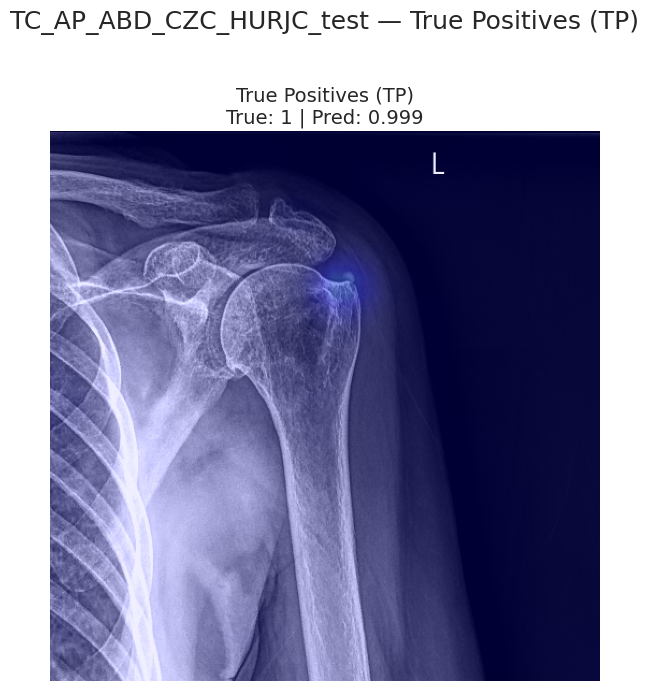

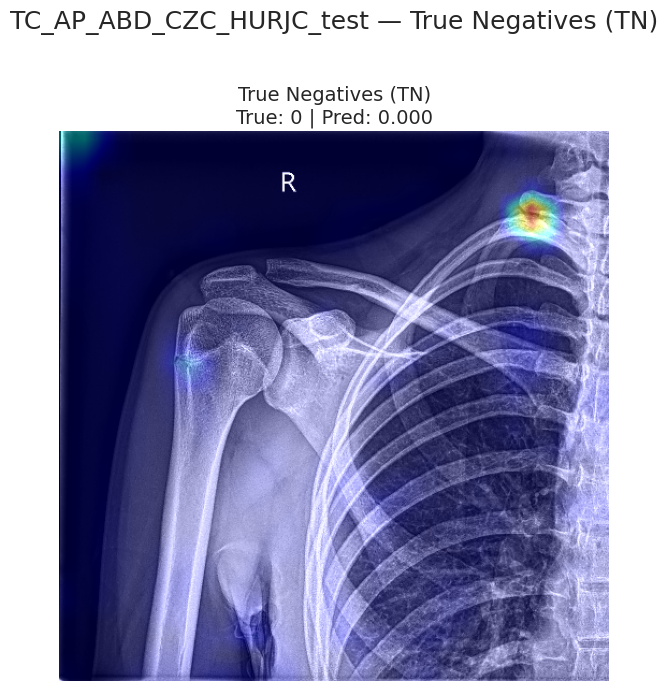

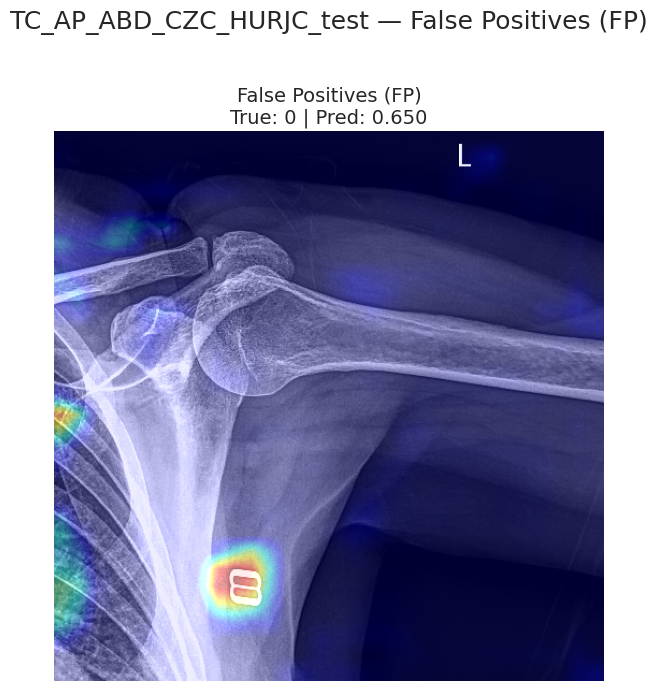

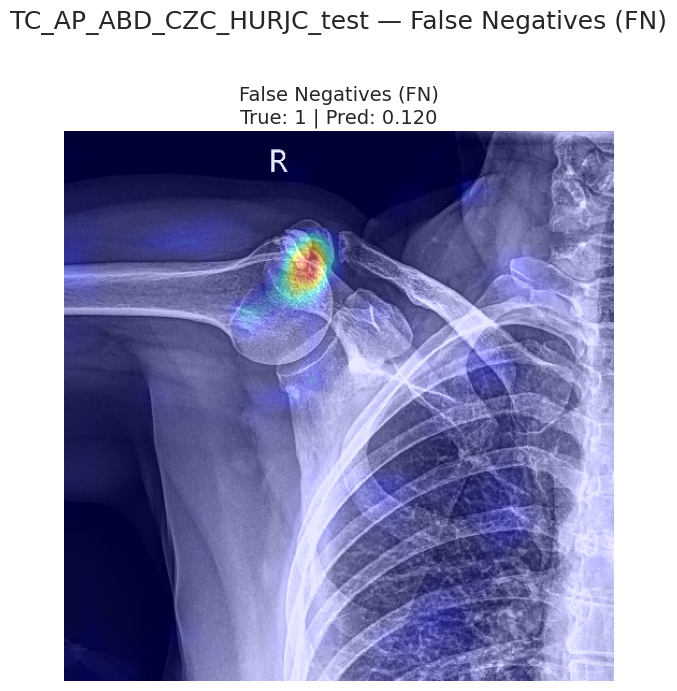


📌 Showing representative examples for subset: TC_AP_ABD_HRJ_HURJC_test


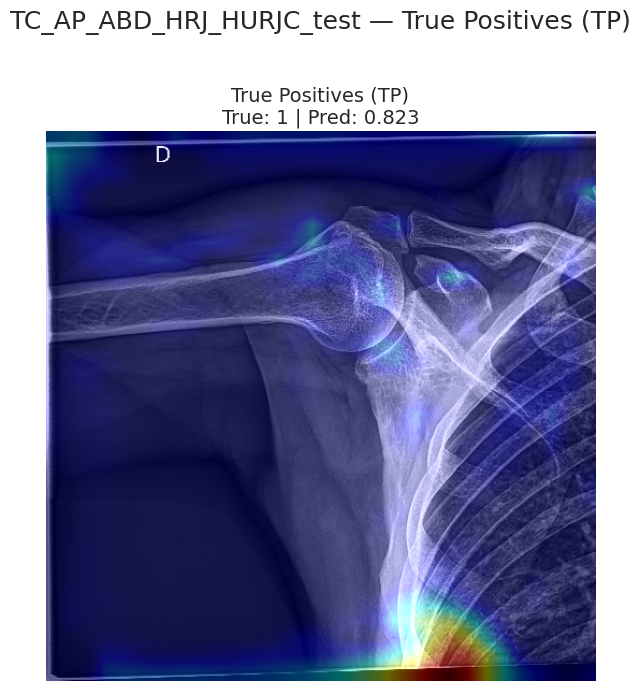

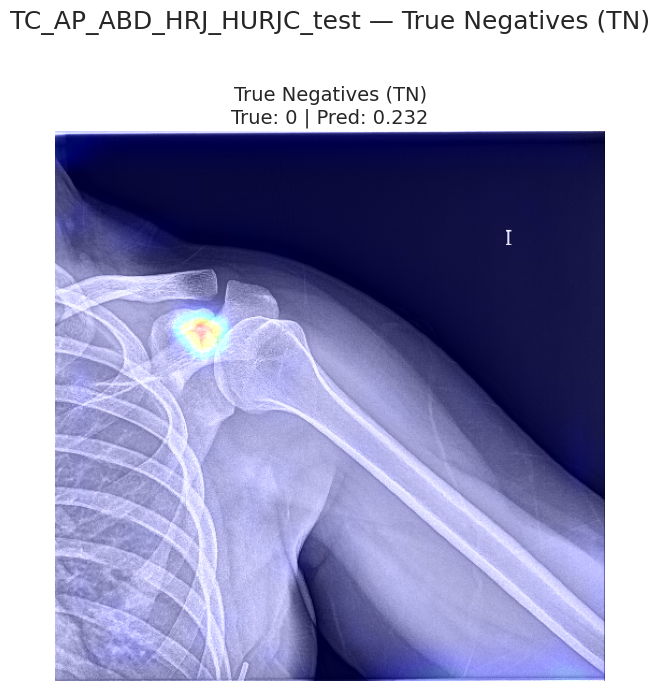

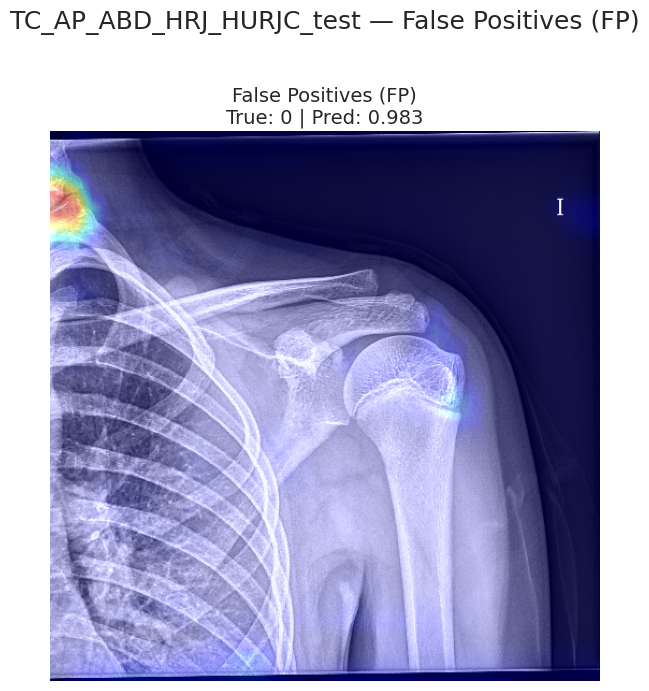

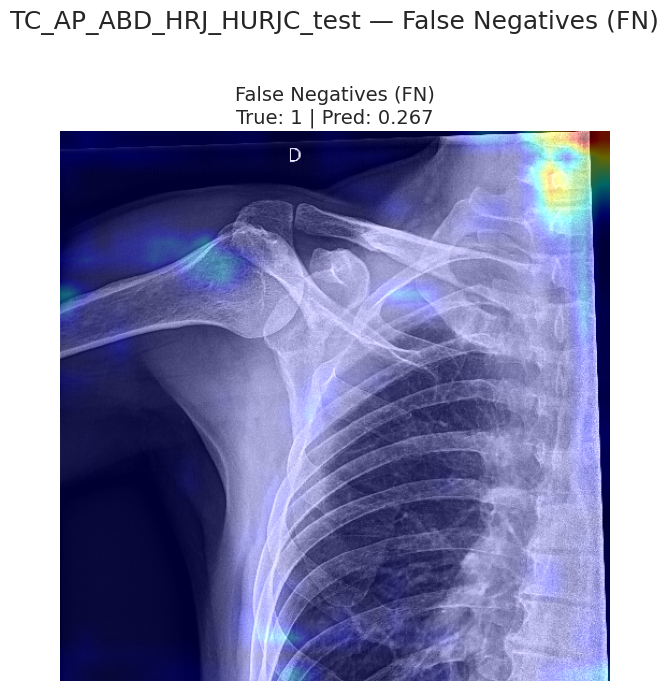


📌 Showing representative examples for subset: TC_AP_ABD_RAD_HURJC_test


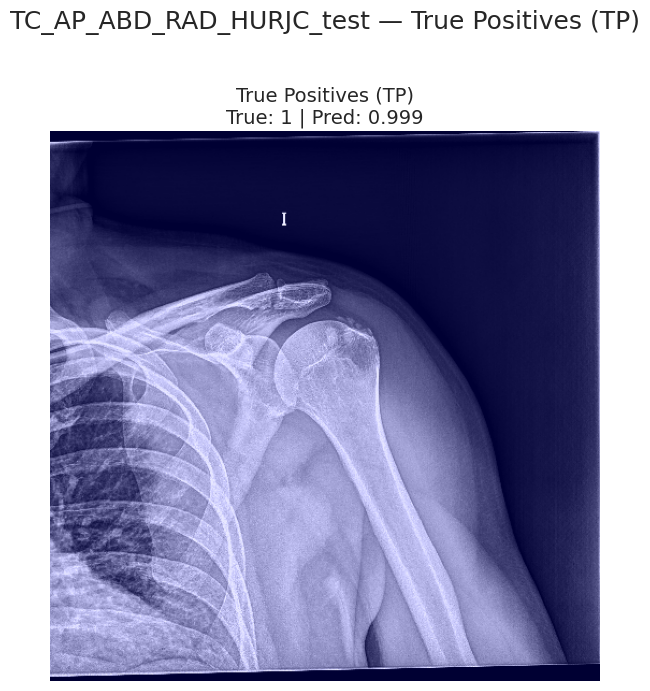

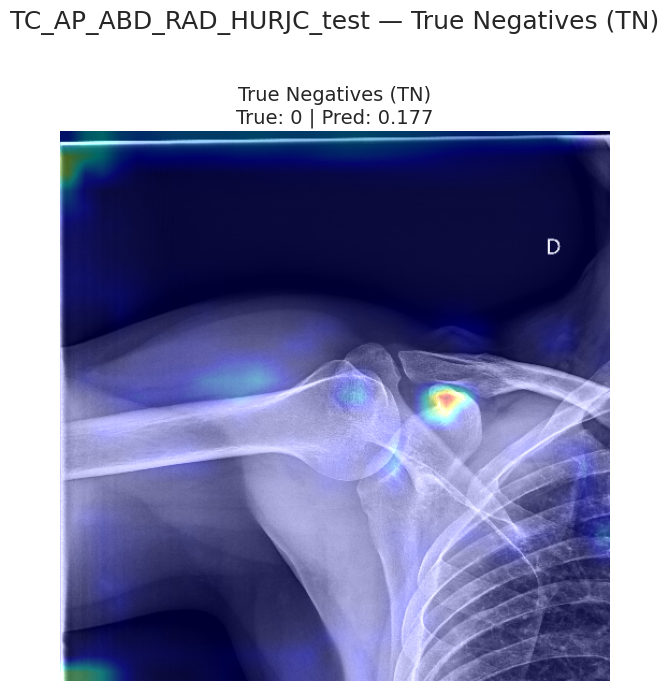

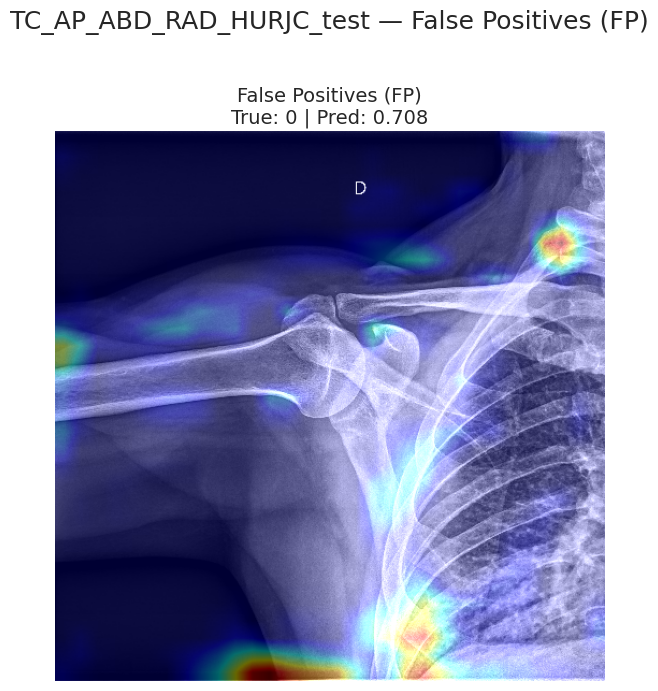

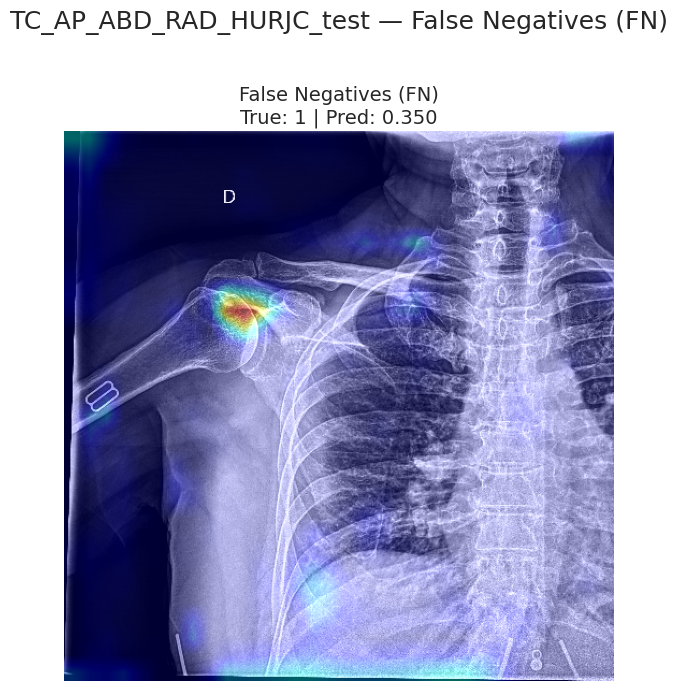


📌 Showing representative examples for subset: TC_AP_ABD_MIN_HURJC_test


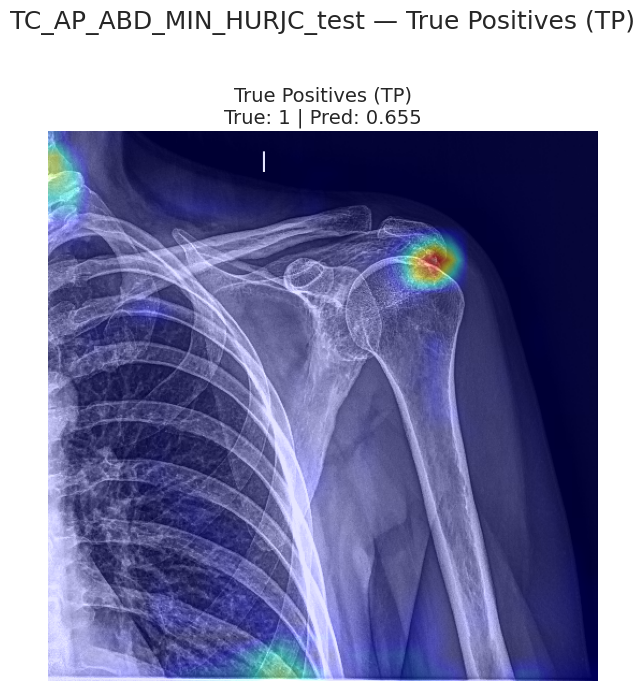

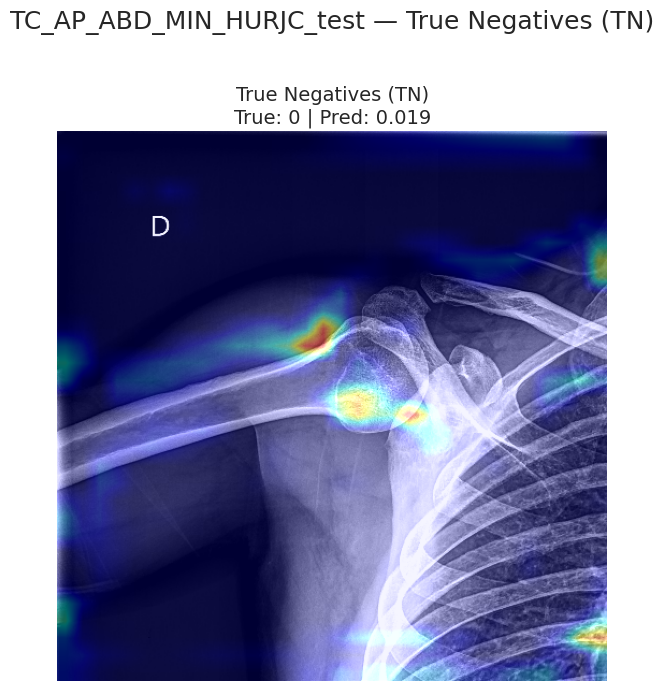

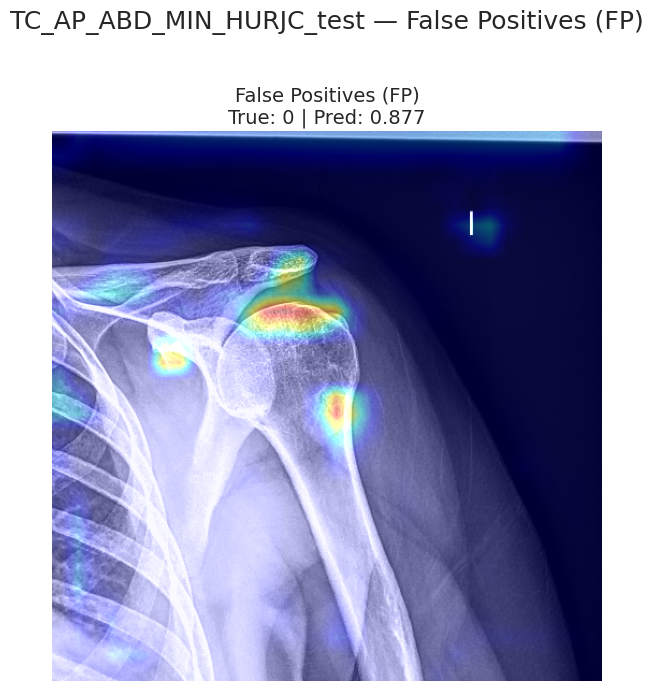

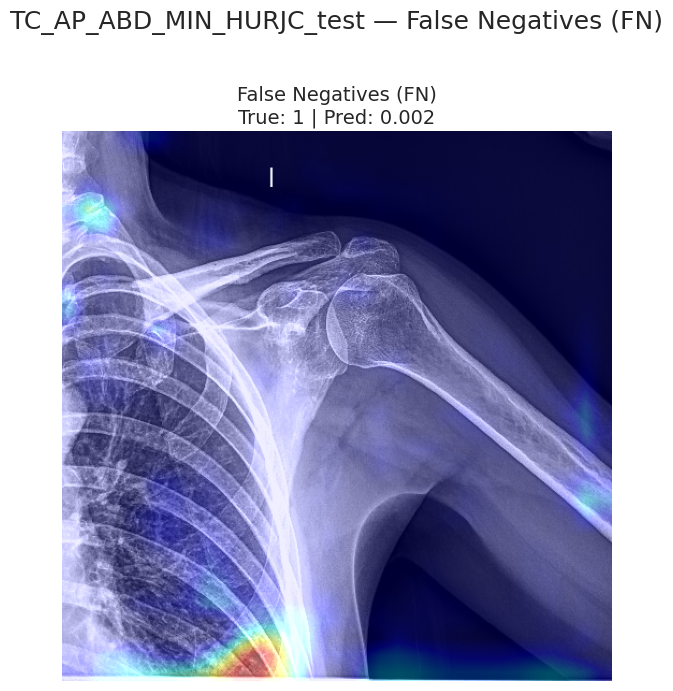

✅ Visualization completed.


In [19]:
# Display representative Grad-CAM heatmaps 
plot_representative_heatmaps(heatmaps_dict, y_true_dict, y_pred_dict, max_examples=1)

print("✅ Visualization completed.")

### **7. Summary and Conclusions**

In this internal validation experiment, the CNN trained only on internal and external rotation views at Institution 1 showed a clearly asymmetric behavior when evaluated on AP and AB projections. On AP radiographs, the model maintained a clinically useful performance, with an AUC close to 0.88 and a reasonable balance between sensitivity and specificity, indicating that the network can transfer part of the knowledge learned on training-like views to a different but still anatomically similar projection.

In contrast, performance on AB views was markedly poorer, with an AUC close to 0.5 and low sensitivity, essentially approaching random behavior. This degradation highlights the strong impact of geometric and anatomical changes induced by abduction on the visibility and spatial configuration of tendon calcifications. It also shows that, even within the same institution and imaging service, a CNN trained on a restricted set of projections cannot be assumed to generalize reliably to substantially different acquisition geometries.

Grad-CAM heatmaps reinforced this interpretation: on AP images, correctly classified cases showed focused activations over plausible anatomical regions corresponding to tendon calcifications, whereas in AB projections the activations were often dispersed over irrelevant structures such as scapula, ribs or peripheral areas. Together, these findings underline that projection shift alone can compromise both performance and interpretability, and they support the need to either (i) include diverse projections during training or (ii) implement explicit geometric normalization strategies if the model is to be deployed robustly across different radiographic views in routine clinical practice.